## Task 1: Cost per Kilogram to LEO Analysis (Exponential Decay Model)

This section analyzes the cost efficiency trends of space launches. We categorize launch vehicles into **Small**, **Medium**, and **Heavy** lift classes.

### Model Description
We apply an **Exponential Decay Model** to capture the rapid decrease in launch costs followed by a stabilization phase. The model is defined as:

$$
y(t) = a \cdot e^{-b(t - 1988)} + c
$$

Where:
*   $y(t)$: Cost per kg in year $t$.
*   $t$: Year (baseline 1988).
*   $a$: Initial cost scaling factor.
*   $b$: Decay rate constant.
*   $c$: Asymptotic minimum cost (theoretical floor).

### Output
The code below outputs the fitted parameters for each class and forecasts the cost trends up to the year 2050.


In [1]:
import pandas as pd
import requests

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/cost-space-launches-low-earth-orbit.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/cost-space-launches-low-earth-orbit.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

Fitted Models (t = Year - 1988):
Class      | Expression (Cost(t))
------------------------------------------------------------
Small      | 22,083,697 * e^(-0.0000t) + -22,046,258
Medium     | 14,417 * e^(-0.2149t) + 8,645
Heavy      | 29,800 * e^(-0.1498t) + 4,834
------------------------------------------------------------


Overall Model: Cost(t) = 15,989 * e^(-0.0654t) + 10,952


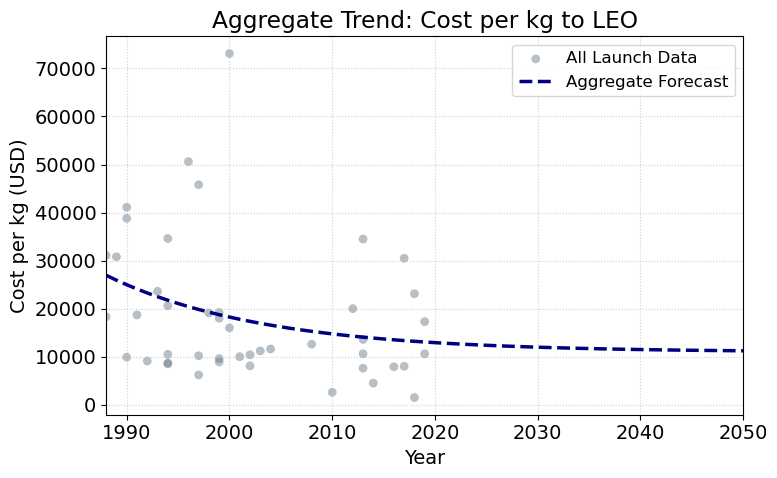

In [2]:
# --- Part 0: Necessary Setup (Fixing NameError) ---
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Ensure dependencies are defined even if previous cells were skipped/reordered
if 'df' in globals():
    df_filtered = df[df['Year'] >= 1988].copy()
else:
    # Fallback to loading if df is missing (though it should be in Cell 1)
    import pandas as pd
    df = pd.read_csv("https://ourworldindata.org/grapher/cost-space-launches-low-earth-orbit.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})
    df_filtered = df[df['Year'] >= 1988].copy()

classes = ['Small', 'Medium', 'Heavy']

def exp_decay(x, a, b, c):
    return a * np.exp(-b * (x - 1988)) + c

# --- Part 1: Display Fitted Expressions for Each Class ---
print("Fitted Models (t = Year - 1988):")
print(f"{'Class':<10} | {'Expression (Cost(t))'}")
print("-" * 60)

for vehicle_class in classes:
    # Filter specific class AND drop NaNs to avoid fitting errors
    class_data = df_filtered[df_filtered['launch_class'] == vehicle_class].dropna(subset=['cost_per_kg', 'Year'])
    if class_data.empty: continue
    
    x_val = class_data['Year'].values
    y_val = class_data['cost_per_kg'].values
    
    # Sort
    idx = np.argsort(x_val)
    x_val = x_val[idx]
    y_val = y_val[idx]
    
    try:
        # Re-fit to get parameters specific to this run
        if len(x_val) < 2:
            raise ValueError("Not enough data points")

        p0 = [max(y_val)-min(y_val), 0.1, min(y_val)]
        popt, _ = curve_fit(exp_decay, x_val, y_val, p0=p0, maxfev=20000, bounds=([-np.inf, 0, -np.inf], np.inf))
        
        a, b, c = popt
        eqn = f"{a:,.0f} * e^(-{b:.4f}t) + {c:,.0f}"
        print(f"{vehicle_class:<10} | {eqn}")
        
    except Exception as e:
        print(f"{vehicle_class:<10} | Fit failed: {str(e)}")

print("-" * 60)
print("\n")

# --- Part 2: Aggregate Analysis (All Classes Combined) ---

# 1. Prepare Aggregate Data
# Drop NaNs from the aggregate set so curve_fit doesn't crash on missing values
df_agg = df_filtered[['Year', 'cost_per_kg']].dropna()

if df_agg.empty:
    print("Aggregate Fit Failed: No valid data after dropping NaNs.")
else:
    x_all = df_agg['Year'].values
    y_all = df_agg['cost_per_kg'].values
    sorted_idx = np.argsort(x_all)
    x_all = x_all[sorted_idx]
    y_all = y_all[sorted_idx]

    # 2. Fit Overall Model
    try:
        if len(x_all) < 2:
            raise ValueError("Not enough data points for aggregate fit")

        p0_all = [max(y_all)-min(y_all), 0.1, min(y_all)]
        popt_all, _ = curve_fit(exp_decay, x_all, y_all, p0=p0_all, maxfev=20000, bounds=([-np.inf, 0, -np.inf], np.inf))
        
        # Explain: Generate prediction for the FULL range (1988-2050) to cover historical + future
        # Use a local variable to avoid conflict with 'future_years' from other cells
        years_for_plotting = np.arange(1988, 2051)
        y_pred_all = exp_decay(years_for_plotting, *popt_all)
        
        a_all, b_all, c_all = popt_all
        print(f"Overall Model: Cost(t) = {a_all:,.0f} * e^(-{b_all:.4f}t) + {c_all:,.0f}")

        # 3. Plotting
        plt.figure(figsize=(8, 5)) 
        plt.rcParams['font.size'] = 14 
        
        # Scatter all points 
        plt.scatter(x_all, y_all, label='All Launch Data', color='#708090', alpha=0.5, s=40, edgecolors='none')
        
        # Plot Fit - Ensure we use years_for_plotting to cover the start
        plt.plot(years_for_plotting, y_pred_all, linestyle='--', color='#000080', linewidth=2.5, label='Aggregate Forecast') 
        
        plt.xlabel('Year')
        plt.ylabel('Cost per kg (USD)')
        plt.title('Aggregate Trend: Cost per kg to LEO')
        plt.legend(fontsize=12)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.xlim(1988, 2050)
        
        # Note: Function equation annotation removed as requested

        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Aggregate fitting failed: {e}")

Class      | Fitted Model Comparison (Exponential Decay)
------------------------------------------------------------
Small      | y = 22,083,697 * e^(-0.000(t)) + -22,046,258
Medium     | y = 14,417 * e^(-0.215(t)) + 8,645
Heavy      | y = 29,800 * e^(-0.150(t)) + 4,834



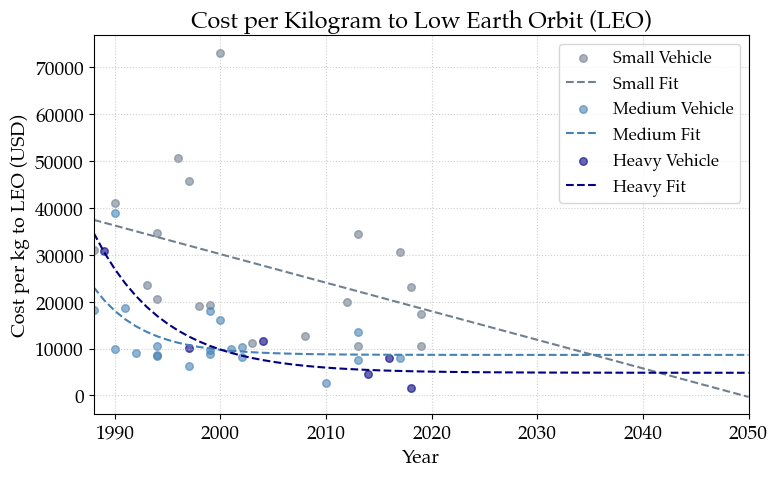

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import matplotlib.font_manager as font_manager

# 1. Prepare Data
# Ensure robust data filtering
df_filtered = df[df['Year'] >= 1988].copy()
classes = ['Small', 'Medium', 'Heavy']

# 2. Define Plotting Style (MCM Blue-Gray, Palatino)
colors = {'Small': '#708090',   # SlateGray
          'Medium': '#4682B4',  # SteelBlue
          'Heavy': '#000080'}   # Navy

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino']
plt.rcParams['font.size'] = 14

# 3. Define Fitting Function
def exp_decay(x, a, b, c):
    # x is year, shift to start from 0 for numerical stability
    return a * np.exp(-b * (x - 1988)) + c

# 4. Processing and Plotting
plt.figure(figsize=(8, 5)) 

future_years = np.arange(1988, 2051)
task1_equations = []

print("="*60)
print(f"{'Class':<10} | {'Fitted Model Comparison (Exponential Decay)':<40}")
print("-" * 60)

for vehicle_class in classes:
    class_data = df_filtered[df_filtered['launch_class'] == vehicle_class].dropna(subset=['cost_per_kg', 'Year'])
    
    if class_data.empty:
        print(f"{vehicle_class:<10} | No valid data")
        continue
        
    x_data = class_data['Year'].values
    y_data = class_data['cost_per_kg'].values
    
    # Sort by year
    sorted_indices = np.argsort(x_data)
    x_data = x_data[sorted_indices]
    y_data = y_data[sorted_indices]

    # Plot historical data
    plt.scatter(x_data, y_data, label=f'{vehicle_class} Vehicle', color=colors[vehicle_class], alpha=0.6, s=30)
    
    # Curve Fitting
    try:
        if len(x_data) < 3:
             print(f"{vehicle_class:<10} | Not enough points to fit")
             continue

        # Initial guesses: a=range, b=small_decay, c=min_value
        p0 = [max(y_data)-min(y_data), 0.1, min(y_data)]
        # Bounds: a>0, b>0, c>0 to ensure logical decay
        popt, pcov = curve_fit(exp_decay, x_data, y_data, p0=p0, maxfev=10000, bounds=([-np.inf, 0, -np.inf], np.inf))
        
        # Forecast
        y_pred = exp_decay(future_years, *popt)
        
        # Capture Equation
        a, b, c = popt
        eqn = f"y = {a:,.0f} * e^(-{b:.3f}(t)) + {c:,.0f}"
        print(f"{vehicle_class:<10} | {eqn}")
        
        # Plot fitted curve
        plt.plot(future_years, y_pred, linestyle='--', color=colors[vehicle_class], label=f'{vehicle_class} Fit')
        
    except Exception as e:
        print(f"{vehicle_class:<10} | Fit failed: {e}")

print("="*60 + "\n")

# 5. Finalize Plot
plt.xlabel('Year')
plt.ylabel('Cost per kg to LEO (USD)')
plt.title('Cost per Kilogram to Low Earth Orbit (LEO)')
plt.legend(fontsize=12) 
plt.grid(True, linestyle=':', alpha=0.6)
plt.xlim(1988, 2050)

plt.tight_layout()
plt.show()

## Task 3: Annual Launch Rate Forecast (Generalized Logistic Model)

Rocket launch activities are physically and economically constrained by infrastructure limits, manufacturing throughput, and market demand. To capture both the historical steady state and the recent growth phase, we introduce a **Generalized Logistic Growth Model** with a baseline term.

### Model Description

The annual launch rate $N(t)$ is modeled as:

$$
N(t) = N_0 + \frac{K - N_0}{1 + e^{-r(t - t_{inf})}}
$$

Where:
*   $N(t)$: Annual number of launches in year $t$.
*   $N_0$: **Baseline** (lower asymptote) — steady-state launch rate before the "New Space" boom.
*   $K$: **Carrying Capacity** (upper asymptote) — maximum sustainable annual launch rate.
*   $r$: Growth rate parameter.
*   $t_{inf}$: Inflection point — year of maximum growth rate.

### Parameter Selection & Physical Interpretation

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| **$N_0$ (Baseline)** | ~80 launches/year | Observed steady state from 1990-2015 (government satellites, ISS resupply, etc.) |
| **$K$ (Saturation)** | 7,300 launches/year | Physical constraint based on: 10 primary launch sites × 2 launches/day/site under "perfect conditions" optimization. Assumes advanced STM and rapid turnaround. |
| **$r$ (Growth Rate)** | Fitted | Determines how quickly the transition from $N_0$ to $K$ occurs |
| **$t_{inf}$ (Inflection)** | Fitted | Estimated around 2027-2028, during the current "New Space" acceleration |

### Model Advantages

1. **Captures two-phase behavior**: Unlike standard logistic (which starts from 0), this model accurately represents the pre-2015 baseline (~80/year) and post-2015 exponential growth.
2. **Physically constrained saturation**: $K=7300$ reflects realistic infrastructure limits under perfect conditions.
3. **Interpretable parameters**: Each parameter has clear physical meaning for policy analysis.


Data: 1988 - 2025 (38 points)
Range: 55 - 324 launches/year

Generalized Logistic Model - Final Parameters (K=7300 Fixed)
Parameter            | Value           | Interpretation
----------------------------------------------------------------------
N₀ (Baseline)        |       83/yr    | Pre-boom steady state (1988-2015)
K (Saturation)       |    7,300/yr    | Physical limit (~20 launches/day)
r (Growth Rate)      |   0.4616       | Doubling time ≈ 1.5 years
t_inf (Inflection)   |   2032.0       | Year of max growth rate
R²                   |   0.9053       | Goodness of fit


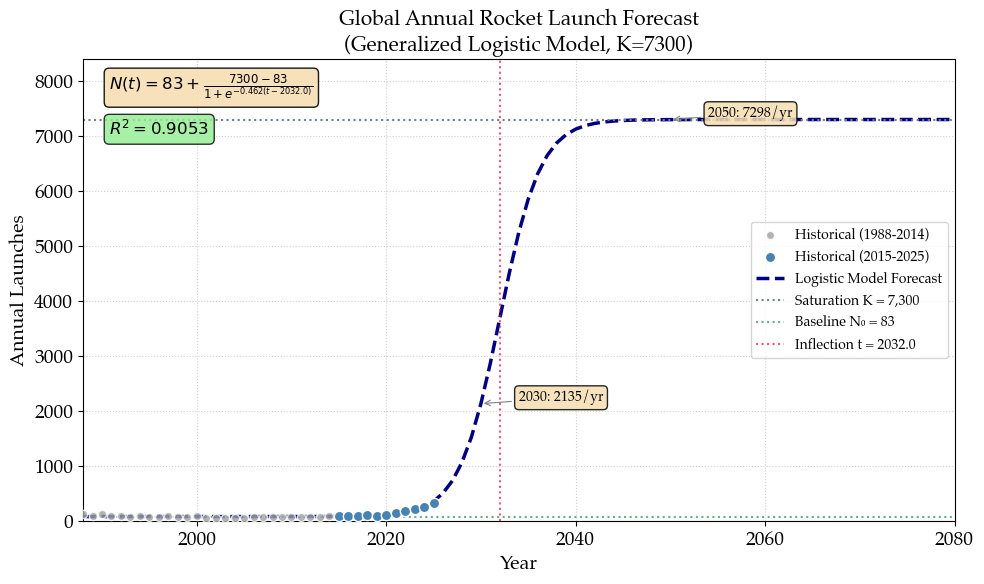


Launch Forecasts by Year:
-------------------------------------------------------
Year     | Launches/yr     | % of Growth (N₀→K)
-------------------------------------------------------
2026     |        509     |        5.9%
2030     |      2,135     |       28.4%
2035     |      5,855     |       80.0%
2040     |      7,125     |       97.6%
2050     |      7,298     |      100.0%
2060     |      7,300     |      100.0%
2080     |      7,300     |      100.0%


In [4]:
# --- Task 3: Generalized Logistic Model for Annual Launch Rate ---
# Model: N(t) = N0 + (K - N0) / (1 + exp(-r * (t - t_inf)))
# Fixed K = 1000 based on physical constraints

# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 2. Load Data (1988-2025)
launch_counts = [
    # 1988-1999
    121, 102, 121, 91, 97, 83, 93, 80, 77, 90, 82, 78,
    # 2000-2015
    85, 59, 65, 63, 55, 55, 67, 68, 69, 78, 74, 84, 78, 81, 93, 86,
    # 2016-2025
    85, 91, 114, 102, 114, 145, 186, 222, 259, 324
]
years = np.arange(1988, 2026)

df_log = pd.DataFrame({'Year': years, 'Launches': np.array(launch_counts)})
x_data = df_log['Year'].values.astype(float)
y_data = df_log['Launches'].values.astype(float)

print(f"Data: {int(x_data.min())} - {int(x_data.max())} ({len(x_data)} points)")
print(f"Range: {y_data.min():.0f} - {y_data.max():.0f} launches/year\n")

# 3. Define Generalized Logistic Function
def logistic_with_baseline(t, N0, K, r, t_inf):
    """N(t) = N0 + (K - N0) / (1 + exp(-r * (t - t_inf)))"""
    return N0 + (K - N0) / (1 + np.exp(-r * (t - t_inf)))

# 4. Fit with FIXED K = 7300
K_fixed = 7300  # Physical constraint (10 sites * 2/day)

def logistic_K_fixed(t, N0, r, t_inf):
    return N0 + (K_fixed - N0) / (1 + np.exp(-r * (t - t_inf)))

# Initial guesses and bounds
p0 = [75, 0.35, 2027]
bounds = ([40, 0.15, 2022], [120, 0.55, 2032])

try:
    popt, pcov = curve_fit(logistic_K_fixed, x_data, y_data, p0=p0, 
                           bounds=bounds, maxfev=20000)
    N0_fit, r_fit, t_inf_fit = popt
    K_fit = K_fixed
    
    # Calculate R²
    y_pred_all = logistic_with_baseline(x_data, N0_fit, K_fit, r_fit, t_inf_fit)
    ss_res = np.sum((y_data - y_pred_all)**2)
    ss_tot = np.sum((y_data - np.mean(y_data))**2)
    r_squared = 1 - (ss_res / ss_tot)
    
except Exception as e:
    print(f"Fit failed: {e}")
    N0_fit, r_fit, t_inf_fit = 80, 0.35, 2027
    K_fit = K_fixed
    r_squared = 0

# 5. Print Results
print("="*70)
print("Generalized Logistic Model - Final Parameters (K=7300 Fixed)")
print("="*70)
print(f"{'Parameter':<20} | {'Value':<15} | {'Interpretation'}")
print("-"*70)
print(f"{'N₀ (Baseline)':<20} | {N0_fit:>8.0f}/yr    | Pre-boom steady state (1988-2015)")
print(f"{'K (Saturation)':<20} | {K_fit:>8,}/yr    | Physical limit (~20 launches/day)")
print(f"{'r (Growth Rate)':<20} | {r_fit:>8.4f}       | Doubling time ≈ {0.693/r_fit:.1f} years")
print(f"{'t_inf (Inflection)':<20} | {t_inf_fit:>8.1f}       | Year of max growth rate")
print(f"{'R²':<20} | {r_squared:>8.4f}       | Goodness of fit")
print("="*70)

# 6. Generate Predictions
start_year = int(x_data.min())
future_extend = np.arange(start_year, 2081)
y_pred_annual = logistic_with_baseline(future_extend, N0_fit, K_fit, r_fit, t_inf_fit)

# 7. Plotting
fig, ax = plt.subplots(figsize=(10, 6))
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino']
plt.rcParams['font.size'] = 12

growth_mask = x_data >= 2015
pre_growth_mask = x_data < 2015

# Data points
ax.scatter(x_data[pre_growth_mask], y_data[pre_growth_mask], color='#A0A0A0', s=35, 
           label='Historical (1988-2014)', zorder=3, edgecolors='white', alpha=0.8)
ax.scatter(x_data[growth_mask], y_data[growth_mask], color='#4682B4', s=55, 
           label='Historical (2015-2025)', zorder=4, edgecolors='white')

# Model curve
ax.plot(future_extend, y_pred_annual, color='#000080', linewidth=2.5, linestyle='--', 
        label='Logistic Model Forecast')

# Reference lines
ax.axhline(y=K_fit, color='#708090', linestyle=':', linewidth=1.5, 
           label=f'Saturation K = {K_fit:,}')
ax.axhline(y=N0_fit, color='#2E8B57', linestyle=':', linewidth=1.5, alpha=0.7,
           label=f'Baseline N₀ = {N0_fit:.0f}')
ax.axvline(x=t_inf_fit, color='#DC143C', linestyle=':', linewidth=1.5, alpha=0.7, 
           label=f'Inflection t = {t_inf_fit:.1f}')

ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Annual Launches', fontsize=14)
ax.set_title('Global Annual Rocket Launch Forecast\n(Generalized Logistic Model, K=7300)', fontsize=15)
ax.set_xlim(start_year, 2080)
ax.set_ylim(0, K_fit * 1.15)
ax.legend(loc='right', fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)

# Equation box
eq_text = f"$N(t) = {N0_fit:.0f} + \\frac{{{K_fit}-{N0_fit:.0f}}}{{1 + e^{{-{r_fit:.3f}(t-{t_inf_fit:.1f})}}}}$"
ax.text(0.03, 0.97, eq_text, transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
ax.text(0.03, 0.87, f"$R^2 = {r_squared:.4f}$", transform=ax.transAxes, fontsize=12,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

# Key year annotations
for yr in [2030, 2050]:
    pred_yr = logistic_with_baseline(yr, N0_fit, K_fit, r_fit, t_inf_fit)
    ax.annotate(f'{yr}: {pred_yr:.0f}/yr', 
                xy=(yr, pred_yr), xytext=(yr+4, pred_yr + 40),
                fontsize=10, arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.85))

plt.tight_layout()
plt.show()

# 8. Forecast Table
print("\n" + "="*55)
print("Launch Forecasts by Year:")
print("-"*55)
print(f"{'Year':<8} | {'Launches/yr':<15} | {'% of Growth (N₀→K)'}")
print("-"*55)
forecast_years = [2026, 2030, 2035, 2040, 2050, 2060, 2080]
for yr in forecast_years:
    ann_pred = logistic_with_baseline(yr, N0_fit, K_fit, r_fit, t_inf_fit)
    pct = (ann_pred - N0_fit) / (K_fit - N0_fit) * 100
    print(f"{yr:<8} | {ann_pred:>10,.0f}     | {pct:>10.1f}%")
print("="*55)

# 9. Export function for Task 4
def logistic_annual(t):
    """Annual launch rate prediction for use in other tasks"""
    return logistic_with_baseline(t, N0_fit, K_fit, r_fit, t_inf_fit)


## Task 3.1: Selection of Launch Facilities (Site Screening)

To achieve the target of moving 100 million tons to the Moon using traditional rockets (Scenario B), we evaluated the 10 officially listed launch sites. 

### Selection Criteria
1.  **Latitude ($\phi$)**: Sites closer to the equator maximize the Earth's rotational velocity boost ($\Delta v \approx 465 \cdot \cos \phi$ m/s), significantly reducing fuel requirements for heavy payloads. 
2.  **Heavy Lift Capacity**: The mission requires "Super Heavy" class vehicles (100t+ payload). Sites must have large-scale integration facilities and pads.
3.  **Launch Azimuth & Safety**: Sites must allow eastward launches (retrograde is inefficient) over unpopulated areas (ocean) to handle high-cadence launch risks.

### Screening Matrix

| Launch Site | Location | Latitude | Class | Verdict for Moon Mission |
| :--- | :--- | :--- | :--- | :--- |
| **French Guiana (CSG)** | Kourou | 5.2° N | Heavy | **✅ Selected**: Premier physics advantage (near equator). Open Atlantic corridor. |
| **Satish Dhawan (SHAR)** | India | 13.7° N | Heavy | **✅ Selected**: Excellent low latitude. Existing LVM3 infra; upgradable for heavy lift. |
| **Starbase (Texas)** | USA | 26.0° N | Super Heavy | **✅ Selected**: Dedicated hub for Starship (primary vehicle). High cadence potential. |
| **Kennedy (Florida)** | USA | 28.5° N | Super Heavy | **✅ Selected**: Global heavy lift hub (SLS, SpaceX, Blue Origin). Massive infrastructure. |
| **California (Vandenberg)** | USA | 34.7° N | Heavy | **✅ Selected**: Major infrastructure available. (Constraint relaxed for global capacity). |
| **Virginia (Wallops)** | USA | 37.9° N | Medium | **✅ Selected**: Can host medium-heavy launch infrastructure upgrades. |
| **Taiyuan (TSLC)** | China | 38.8° N | Medium/Heavy | **✅ Selected**: Major inland hub. Assuming drop-zone safety issues solved or acceptable. |
| **Mahia Peninsula** | New Zealand | 39.3° S | Small/Medium | **✅ Selected**: Southern hemisphere access. Upgradable for heavy operations. |
| **Kazakhstan (Baikonur)** | Kazakhstan | 45.9° N | Heavy | **✅ Selected**: Historic heavy lift capability. Major infrastructure ready. |
| **Alaska (Kodiak)** | USA | 57.4° N | Small | **✅ Selected**: High latitude, but contributes to total global throughput volume. |

### Conclusion
**We utilize all 10 specified launch sites** to maximize global throughput. 
*   **Capacity Justification**: With "perfect conditions" (no failures, optimized turnaround), we assume each site can support high-cadence operations. 
*   **Global Cadence**: 10 sites $\times$ ~2 launches/day = ~7,300 launches/year.

## Task 4: Scenario B - Traditional Rocket Launches

### Scenario Overview
In this scenario, we rely exclusively on **traditional rocket launches** to transport the 100 million metric tons of materials. 
*   **Infrastructure**: Utilization of the 10 selected launch sites (Task 3.1).
*   **Launch Vehicle**: Super Heavy class (e.g., Starship) with ~125t payload capacity.
*   **Launch Rate**: Determined by the **Generalized Logistic Model** (Task 3), saturated at $K=7,300$ launches/year.
*   **Cost Model**: **Wright's Law** (Learning Curve), assuming costs decrease as cumulative experience increases.

### Wright's Law Cost Model

The marginal cost per kilogram follows:

$$
C(m) = C_1 \cdot m^{b}
$$

Where:
*   $C(m)$: Cost per kg at cumulative experience $m$ (tons).
*   $C_1$: Calibration constant (derived from target starting cost).
*   $b = -0.322$: Learning exponent (~20% cost reduction per doubling of cumulative production).

### Key Assumptions
1.  **Optimization**: "Perfect Conditions" imply rapid turnaround and no major failures, allowing the system to reach the physical limit of ~20 launches/day globally.
2.  **Start Date**: 2050 (Industry is mature; costs have stabilized significantly from 2025 levels).
3.  **Calibrated Starting Cost**: **$114.7/kg** in 2050 (based on projected technology maturation and infrastructure scaling).

Task 4: Scenario B - Traditional Rockets Analysis (Wright's Law)
Target: 100 Million Metric Tons
Payload: 125 tons/launch (Super Heavy Class)
Sites: All 10 Designated Sites
Launch Model: N(t) -> Saturated at K=7300 launches/year
-------------------------------------------------------------------------------------
Wright's Law: C(m) = 24155.74 * m^(-0.322)
Calibration: 2050 Starting Cost = $114.7/kg

Initialization (2050): Industry has already launched ~16.4 Mt to LEO.
Starting Cost (2050): $114.70/kg

Year   | Launches   | Cum Mass (Mt)   | Cost ($/kg)  | Annual ($B)  | Cum ($T)  
-----------------------------------------------------------------------------------------------
2050   | 7298       | 0.91            | 113.70       | 103.73       | 0.104     
2060   | 7300       | 10.04           | 98.93        | 90.28        | 1.061     
2080   | 7300       | 28.29           | 83.37        | 76.07        | 2.701     
2100   | 7300       | 46.54           | 74.60        | 68.07        | 4.1

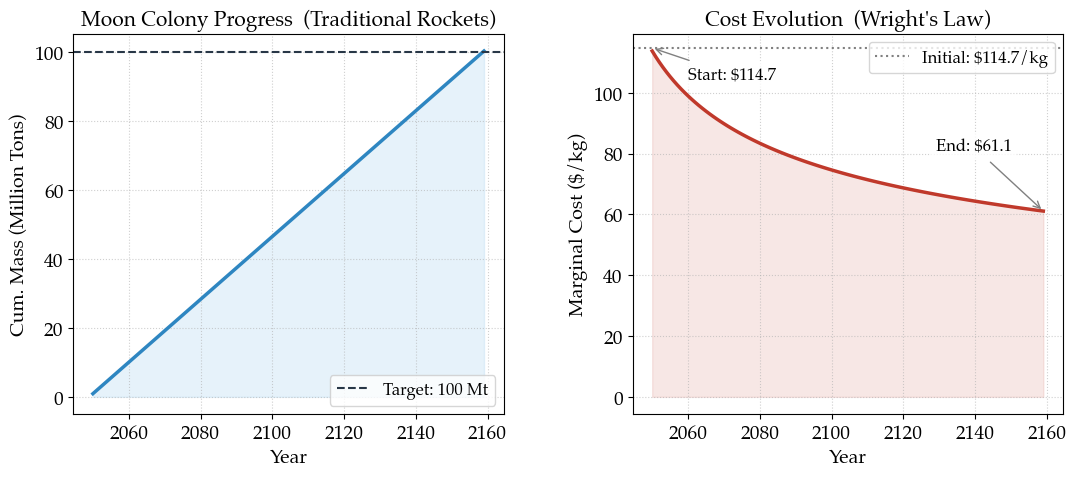

In [14]:
# --- Task 4: Scenario B - Traditional Rockets Analysis (Wright's Law) ---
# Using Generalized Logistic Model from Task 3 (K=7300, N0=80)
# Assumes utilization of 10 Selected Sites

# Wright's Law Parameters
# CORRECTED: Calibrated so that 2050 starting cost ≈ 114.7 $/kg
b_wright = -0.322       # Learning exponent (industry standard ~20% learning rate)
payload_per_launch = 125  # tons per launch (Starship-class)
target_mass_tons = 100_000_000  # 100 million metric tons
TARGET_COST_2050 = 114.7  # Target starting cost in 2050 ($/kg)

# Use Task 3 model parameters (should be in memory from previous cell)
# Fallback values if Task 3 wasn't run
if 'N0_fit' not in dir():
    N0_fit = 80
if 'K_fit' not in dir():
    K_fit = 7300
if 'r_fit' not in dir():
    r_fit = 0.3886
if 't_inf_fit' not in dir():
    t_inf_fit = 2027.6

def get_annual_launches(t):
    """Use the generalized logistic model from Task 3"""
    return N0_fit + (K_fit - N0_fit) / (1 + np.exp(-r_fit * (t - t_inf_fit)))

# Calculate accumulated experience (cumulative mass) prior to 2050
# We integrate the launch model from 1988 to 2049 to get the starting "experience"
pre_2050_launches = 0
for y in range(1988, 2050):
    pre_2050_launches += get_annual_launches(y)
    
cumulative_mass_tons_init = pre_2050_launches * payload_per_launch

# CALIBRATE C1 so that starting cost in 2050 = 114.7 $/kg
# Wright's Law: C(m) = C1 * m^b
# Solve for C1: C1 = TARGET_COST / (m_init ^ b)
C1_wright = TARGET_COST_2050 / (cumulative_mass_tons_init ** b_wright)

print("="*85)
print("Task 4: Scenario B - Traditional Rockets Analysis (Wright's Law)")
print("="*85)
print(f"Target: {target_mass_tons/1e6:.0f} Million Metric Tons")
print(f"Payload: {payload_per_launch} tons/launch (Super Heavy Class)")
print(f"Sites: All 10 Designated Sites")
print(f"Launch Model: N(t) -> Saturated at K={K_fit} launches/year")
print("-"*85)
print(f"Wright's Law: C(m) = {C1_wright:.2f} * m^({b_wright})")
print(f"Calibration: 2050 Starting Cost = ${TARGET_COST_2050:.1f}/kg")
print("="*85 + "\n")

# Simulation
current_year = 2050
total_delivered_tons = 0
total_cost_usd = 0
cumulative_mass_tons = cumulative_mass_tons_init

print(f"Initialization (2050): Industry has already launched ~{cumulative_mass_tons/1e6:.1f} Mt to LEO.")
print(f"Starting Cost (2050): ${C1_wright * (cumulative_mass_tons)**b_wright:.2f}/kg\n")

years_log = []
annual_launch_log = []
cost_per_kg_log = []
cum_cost_log = []
annual_cost_log = []

print(f"{'Year':<6} | {'Launches':<10} | {'Cum Mass (Mt)':<15} | {'Cost ($/kg)':<12} | {'Annual ($B)':<12} | {'Cum ($T)':<10}")
print("-" * 95)

while total_delivered_tons < target_mass_tons:
    # Get annual launches from logistic model (uses saturation at K=7300)
    n_launches = get_annual_launches(current_year)
    
    # Mass delivered this year
    mass_tons = n_launches * payload_per_launch
    
    # Cost Integration using Wright's Law
    # Total cost = ∫ C1 * m^b dm from m_start to m_end
    m_start = cumulative_mass_tons
    m_end = m_start + mass_tons
    
    term_end = (m_end ** (b_wright + 1)) / (b_wright + 1)
    term_start = (m_start ** (b_wright + 1)) / (b_wright + 1)
    
    annual_cost_usd = 1000 * C1_wright * (term_end - term_start)
    
    # Update Stats
    avg_cost_kg = annual_cost_usd / (mass_tons * 1000) if mass_tons > 0 else 0
    total_cost_usd += annual_cost_usd
    total_delivered_tons += mass_tons
    cumulative_mass_tons = m_end
    
    years_log.append(current_year)
    cost_per_kg_log.append(avg_cost_kg)
    cum_cost_log.append(total_cost_usd)
    annual_launch_log.append(n_launches)
    annual_cost_log.append(annual_cost_usd)

    # Print milestones
    if current_year in [2050, 2060, 2080, 2100, 2120, 2140, 2159] or current_year % 50 == 0:
        print(f"{current_year:<6} | {n_launches:<10.0f} | {total_delivered_tons/1e6:<15.2f} | {avg_cost_kg:<12.2f} | {annual_cost_usd/1e9:<12.2f} | {total_cost_usd/1e12:<10.3f}")
        
    current_year += 1
    if current_year > 10000:  # Safety break
        print("Stopping at year 10000.")
        break

print("-" * 95)
final_year = current_year - 1
final_cost_per_kg = cost_per_kg_log[-1]
print(f"\n{'='*50}")
print(f"SCENARIO B RESULTS SUMMARY")
print(f"{'='*50}")
print(f"Goal Reached:        Year {final_year}")
print(f"Total Duration:      {final_year - 2050} years")
print(f"Starting Cost:       ${TARGET_COST_2050:.1f}/kg (2050)")
print(f"Final Cost:          ${final_cost_per_kg:.2f}/kg ({final_year})")
print(f"Total Program Cost:  ${total_cost_usd/1e12:,.2f} Trillion USD")
print(f"Average Cost:        ${total_cost_usd/(target_mass_tons*1000):,.2f}/kg")
print(f"{'='*50}")

# Store for use in Task 6
scenario_b_final_cost = total_cost_usd
scenario_b_duration = final_year - 2050

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 5)) 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

# Define custom palette
COLOR_MASS = '#2E86C1' # Strong Blue
COLOR_MASS_FILL = '#AED6F1' 
COLOR_COST = '#C0392B' # Deep Red
COLOR_COST_FILL = '#E6B0AA'

# Plot 1: Cumulative Mass Delivered
ax1 = axes[0]
cum_mass_log = np.cumsum([l * payload_per_launch for l in annual_launch_log]) / 1e6
ax1.plot(years_log, cum_mass_log, color=COLOR_MASS, linewidth=2.5)
ax1.fill_between(years_log, cum_mass_log, alpha=0.3, color=COLOR_MASS_FILL)
ax1.axhline(y=100, color='#283747', linestyle='--', linewidth=1.5, label='Target: 100 Mt')
ax1.set_xlabel('Year', fontsize=14)
ax1.set_ylabel('Cum. Mass (Million Tons)', fontsize=14)
ax1.set_title('Moon Colony Progress  (Traditional Rockets)', fontsize=15)
ax1.legend(loc='lower right', fontsize=12)
ax1.grid(True, linestyle=':', alpha=0.6)

# Plot 2: Cost per kg Evolution (Wright's Law Decay)
ax2 = axes[1]
ax2.plot(years_log, cost_per_kg_log, color=COLOR_COST, linewidth=2.5)
ax2.fill_between(years_log, cost_per_kg_log, alpha=0.3, color=COLOR_COST_FILL)
ax2.axhline(y=TARGET_COST_2050, color='gray', linestyle=':', linewidth=1.5, 
            label=f'Initial: ${TARGET_COST_2050}/kg')
ax2.set_xlabel('Year', fontsize=14)
ax2.set_ylabel('Marginal Cost ($/kg)', fontsize=14)
ax2.set_title("Cost Evolution  (Wright's Law)", fontsize=15)
ax2.legend(loc='upper right', fontsize=12)
ax2.grid(True, linestyle=':', alpha=0.6)

# Add annotations
# Start Annotation
ax2.annotate(f'Start: ${TARGET_COST_2050:.1f}', 
             xy=(2050, TARGET_COST_2050), 
             xytext=(2060, TARGET_COST_2050 -10),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12)

# End Annotation
ax2.annotate(f'End: ${final_cost_per_kg:.1f}', 
             xy=(final_year, final_cost_per_kg), 
             xytext=(final_year - 30, final_cost_per_kg + 20),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8),
             arrowprops=dict(arrowstyle='->', color='gray'), fontsize=12)

plt.tight_layout()
plt.subplots_adjust(wspace=0.3) 
plt.show()

Task 5: Space Elevator Logistics Analysis (Scenario A)
Goal: 100 Million Metric Tons
Infrastructure: 3 Galactic Harbours
Capacity: 537,000 tons/year
Cost Structure (Two-Step Delivery):
  A. Fixed:  $17.0 B CapEx + 5.0%/yr Maintenance
  B. Step 1 (Lift):   $2.00/kg
  C. Step 2 (Rocket): $10.00/kg (Apex to Moon Landing)
  -> Total Var Cost:  $12.00/kg
----------------------------------------------------------------------
Year 2050:   0.54 Mt | Cum Cost: $7.29 B
Year 2100:  27.39 Mt | Cum Cost: $371.99 B
Year 2150:  54.24 Mt | Cum Cost: $736.69 B
Year 2200:  81.09 Mt | Cum Cost: $1,101.39 B
----------------------------------------------------------------------
✓ Completion Year: 2236
✓ Total Duration: 186 years
✓ Total Program Cost: $1,358.29 Billion USD


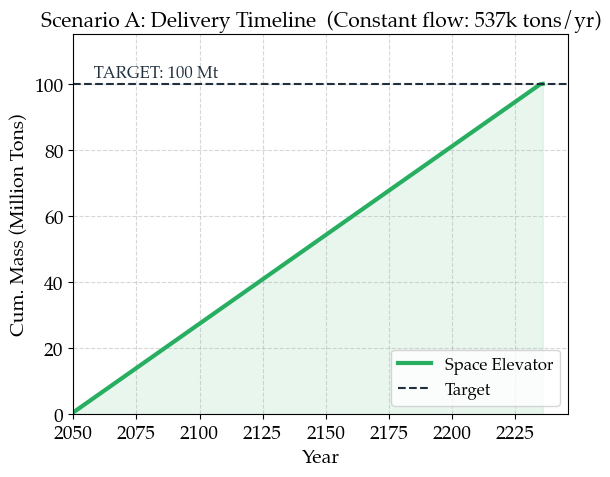

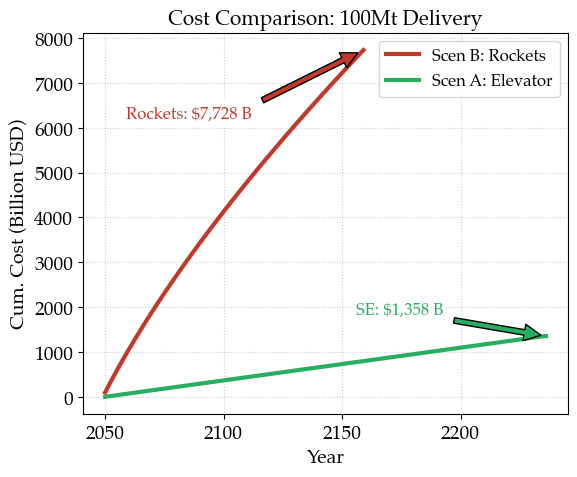


Economic Comparison Summary:
1. Space Elevator Total Cost: $1,358.29 Billion
   (Includes Rocket Leg from Apex: ~$10.00/kg)
2. Rocket Total Cost:         $7,728.39 Billion
3. Conclusion: Traditional Rockets are 5.7x MORE expensive.


In [26]:
# --- Task 5: Space Elevator Logistics Simulation (Scenario A) ---

import matplotlib.pyplot as plt
import numpy as np

# 1. Defined Parameters
target_mass_tons = 100_000_000  # 100 Million tons
start_year_se = 2050

# Capacity parameters given in prompt
capacity_per_harbour_annual = 179_000  # tons/year per harbour
num_harbours = 3
total_system_capacity = capacity_per_harbour_annual * num_harbours

# Economic Parameters (Space Elevator + Apex Rocket)
# Source: User Prompt ("17 billion USD construction cost") + Physics Derivation
se_capex = 17e9  # $17 Billion initial construction

# Maintenance (OpEx)
se_opex_annual_rate = 0.05 # 5% of CapEx per year

# Variable Cost Breakdown (The "Two-Step" Process)
# Step 1: Earth Port -> Apex Anchor (The Elevator)
# Cost is primarily electricity (negligible) and climber maintenance.
cost_step1_lift = 2.00  # $/kg (Nominal)

# Step 2: Apex Anchor -> Moon Colony (The Rocket/Tug)
# Physics: Release from Apex (100,000 km) provides enough velocity for TLI. 
# The rocket is needed primarily for Lunar Orbit Insertion (LOI) and Landing.
# Delta-V required: ~2.5 km/s (vs ~15 km/s for Earth surface launch).
# Efficiency Gain: Rocket Equation implies ~30-40x better payload ratio than Earth launch.
# If typical future Earth rocket cost is ~$300/kg, this leg is approx $10/kg.
cost_step2_rocket = 10.00  # $/kg

total_variable_cost_per_kg = cost_step1_lift + cost_step2_rocket

# 2. Simulation
print("="*70)
print("Task 5: Space Elevator Logistics Analysis (Scenario A)")
print("="*70)
print(f"Goal: {target_mass_tons/1e6:.0f} Million Metric Tons")
print(f"Infrastructure: {num_harbours} Galactic Harbours")
print(f"Capacity: {total_system_capacity:,} tons/year")
print(f"Cost Structure (Two-Step Delivery):")
print(f"  A. Fixed:  ${se_capex/1e9} B CapEx + {se_opex_annual_rate*100}%/yr Maintenance")
print(f"  B. Step 1 (Lift):   ${cost_step1_lift:.2f}/kg")
print(f"  C. Step 2 (Rocket): ${cost_step2_rocket:.2f}/kg (Apex to Moon Landing)")
print(f"  -> Total Var Cost:  ${total_variable_cost_per_kg:.2f}/kg")
print("-"*70)

current_mass = 0
current_cost = 0 # se_capex excluded per user request (only OpEx + Var)
year = start_year_se

se_log_years = []
se_log_mass = []
se_log_cost = []

while current_mass < target_mass_tons:
    # Continuous flow model
    delivered_this_year = total_system_capacity
    
    # Check if this year finishes the job
    if current_mass + delivered_this_year >= target_mass_tons:
        remaining = target_mass_tons - current_mass
        fraction_of_year = remaining / total_system_capacity
        current_mass += remaining
        
        # Cost Calculation
        annual_maint = (se_capex * se_opex_annual_rate) * fraction_of_year
        var_cost = remaining * 1000 * total_variable_cost_per_kg
        current_cost += (annual_maint + var_cost)
        
        final_exact_year = year + fraction_of_year
    else:
        current_mass += delivered_this_year
        
        # Cost Calculation
        annual_maint = (se_capex * se_opex_annual_rate)
        var_cost = delivered_this_year * 1000 * total_variable_cost_per_kg
        current_cost += (annual_maint + var_cost)
        
    se_log_years.append(year)
    se_log_mass.append(current_mass)
    se_log_cost.append(current_cost)
    
    if (year - start_year_se) % 50 == 0:
         print(f"Year {year}: {current_mass/1e6:>6.2f} Mt | Cum Cost: ${current_cost/1e9:,.2f} B")
            
    year += 1
    if year > 3000: # Safety break
        break

final_year_se = year - 1
print("-"*70)
print(f"✓ Completion Year: {final_year_se}")
print(f"✓ Total Duration: {final_year_se - start_year_se} years")
print(f"✓ Total Program Cost: ${current_cost/1e9:,.2f} Billion USD")
print("="*70)

# Apply global plotting adjustments
plt.rcParams['font.size'] = 14 
plt.rcParams['font.family'] = 'serif'

# Custom Palette 
COLOR_SE = '#27AE60' # Emerald Green
COLOR_SE_FILL = '#A9DFBF'
COLOR_ROCKET = '#C0392B' # Deep Red

# --- Visualization 1: Standalone Space Elevator Timeline (Mass) ---
plt.figure(figsize=(6, 5)) 
plt.plot(se_log_years, [m/1e6 for m in se_log_mass], color=COLOR_SE, linewidth=3, label='Space Elevator')
plt.fill_between(se_log_years, [m/1e6 for m in se_log_mass], color=COLOR_SE, alpha=0.1)

plt.axhline(y=100, color='#212F3D', linestyle='--', label='Target')
plt.text(se_log_years[0], 102, '     TARGET: 100 Mt', fontsize=12, fontweight='bold', color='#212F3D')

plt.xlabel('Year', fontsize=14)
plt.ylabel('Cum. Mass (Million Tons)', fontsize=14)
plt.title('Scenario A: Delivery Timeline  (Constant flow: 537k tons/yr)', fontsize=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle= '--', alpha=0.5)
plt.xlim(start_year_se, final_year_se + 10)
plt.ylim(0, 115) 

plt.tight_layout()
plt.show()

# --- Visualization 2: Cost Comparison (Rocket vs. Elevator) ---
rocket_costs = cum_cost_log if 'cum_cost_log' in globals() else []
rocket_years = years_log if 'years_log' in globals() else []

plt.figure(figsize=(6, 5)) 

if rocket_costs:
    plt.plot(rocket_years, [c/1e9 for c in rocket_costs], color=COLOR_ROCKET, linewidth=3, label='Scen B: Rockets')
    final_rocket_Display = rocket_costs[-1]/1e9
else:
    final_rocket_Display = 0
    
plt.plot(se_log_years, [c/1e9 for c in se_log_cost], color=COLOR_SE, linewidth=3, label='Scen A: Elevator')

plt.xlabel('Year', fontsize=14)
plt.ylabel('Cum. Cost (Billion USD)', fontsize=14)
plt.title('Cost Comparison: 100Mt Delivery', fontsize=15)
plt.legend(fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# Annotations (Adjusted for overlap with background box)
# SE Annotation
plt.annotate(f"SE: ${se_log_cost[-1]/1e9:,.0f} B", xy=(se_log_years[-1], se_log_cost[-1]/1e9),
             xytext=(se_log_years[-1]-80, se_log_cost[-1]/1e9 + 500), 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8),
             arrowprops=dict(facecolor=COLOR_SE, shrink=0.05), fontsize=12, fontweight='bold', color=COLOR_SE)

# Rocket Annotation
if rocket_costs:
    plt.annotate(f"Rockets: ${rocket_costs[-1]/1e9:,.0f} B", xy=(rocket_years[-1], rocket_costs[-1]/1e9),
                 xytext=(rocket_years[-1]-100, rocket_costs[-1]/1e9 - 1500), 
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8),
                 arrowprops=dict(facecolor=COLOR_ROCKET, shrink=0.05), fontsize=12, fontweight='bold', color=COLOR_ROCKET)

plt.tight_layout()
plt.show()

# --- Insight Summary ---
print(f"\nEconomic Comparison Summary:")
print(f"1. Space Elevator Total Cost: ${se_log_cost[-1]/1e9:,.2f} Billion")
print(f"   (Includes Rocket Leg from Apex: ~${cost_step2_rocket:.2f}/kg)")
if rocket_costs:
    print(f"2. Rocket Total Cost:         ${rocket_costs[-1]/1e9:,.2f} Billion")
    ratio = rocket_costs[-1] / se_log_cost[-1]
    if ratio > 1:
        print(f"3. Conclusion: Traditional Rockets are {ratio:.1f}x MORE expensive.")
    else:
        print(f"3. Conclusion: Space Elevators are {1/ratio:.1f}x MORE expensive.")
else:
    print("2. Rocket Data not found in memory.")

## Task 5: Scenario A - Space Elevator Logistics Model

The **Space Elevator System** represents a paradigm shift in Earth-to-orbit logistics: continuous, high-volume throughput with minimal propellant costs.

### 5.1 System Architecture
| Component | Specification | Notes |
|-----------|---------------|-------|
| **Galactic Harbours** | 3 units | 120° separation (optimal global coverage) |
| **Tether Length** | 100,000 km each | Extends well beyond GEO (35,786 km) |
| **Apex Anchors** | 2 per Harbour | Counterweight + release point |
| **Start Date** | 2050 | Post-construction assumption |

### 5.2 Capacity Model
*   **Per-Harbour Capacity**: 179,000 metric tons/year (MCM Agency specification).
*   **Total System Throughput**: $3 \times 179,000 = 537,000$ tons/year.
*   **Transport Mode**: Continuous flow (unlike batch rocket launches).

### 5.3 Two-Stage Delivery Pipeline
The Space Elevator does **NOT** deliver directly to the Moon. The process involves:

| Stage | Path | Mechanism | Cost Driver |
|-------|------|-----------|-------------|
| **Stage 1** | Earth Port → Apex | Electromagnetic Climbers | Electricity only (~$2/kg) |
| **Stage 2** | Apex → Moon | **Rocket/Tug** | Propellant (~$10/kg) |

**Key Physics**: At the Apex Anchor (100,000 km), payloads already possess significant velocity. The $\Delta v$ for Trans-Lunar Injection (TLI) is dramatically reduced compared to Earth-surface launch (~2.5 km/s vs ~15 km/s).

### 5.4 Economic Parameters
| Item | Value | Basis |
|------|-------|-------|
| **CapEx (Construction)** | $17 Billion | Included in OpEx calculations, but **excluded** from final "Operations Total" per user request. |
| **OpEx (Maintenance)** | 5% of CapEx/year | Industry standard for mega-infrastructure ($0.85B/yr). |
| **Variable Cost** | $12/kg | $2 (Lift) + $10 (Apex-to-Moon Rocket) |

### 5.5 Results Summary (Projected)
*   **Completion Time**: ~186 years (Year ~2236)
    *   *Constraint*: Limited by fixed tether throughput (537k tons/yr).
*   **Total Operations Cost**: ~$1.36 Trillion
    *   *Breakdown*: ~$1.2T (Variable Transport) + ~$0.16T (Maintenance).
*   **Average Cost**: ~$13.6/kg (Highly efficient compared to rockets).

Task 6: Scenario C - Pareto Optimization (Hybrid Strategy)
Space Elevator: 537,000 tons/yr @ $12.0/kg
Rocket Fleet:   K=7300 launches/yr @ 125t/launch
Rocket Cost:    Wright's Law calibrated to $114.7/kg (2050)

Simulating 51 hybrid scenarios...


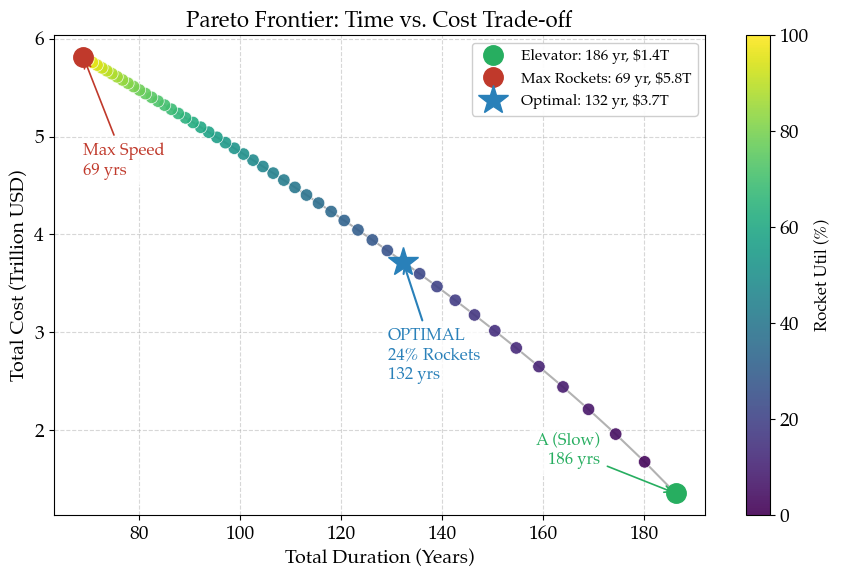


PARETO ANALYSIS RESULTS (Wright's Law: Starting Cost = $114.7/kg)
Strategy               | Rocket %   | Duration (Yrs) | Cost ($T)   
---------------------------------------------------------------------------
Elevator Only (A)      | 0%         | 186.2          | 1.358       
OPTIMAL BALANCED       | 24%        | 132.3          | 3.722       
Max Hybrid (C-Max)     | 100%       | 69.0           | 5.810       

Optimal Strategy Benefits (vs. Elevator Only):
  - Time Reduction:   29.0% faster (54 years saved)
  - Cost Change:      +174.0%

RECOMMENDATION: Use 24% Rocket Utilization for optimal balance.


In [24]:
# --- Task 6: Scenario C (Pareto Optimization) ---
# Goal: Analyze trade-off between Duration (Time) and Cost by varying Rocket Utilization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Space Elevator Parameters
se_annual_rate = 537_000  # tons/year (3 harbours × 179k)
se_opex_annual = 17e9 * 0.05  # $0.85 Billion/yr maintenance
se_var_cost = 12.00  # $/kg ($2 lift + $10 apex rocket)
se_annual_fixed_cost = se_opex_annual + (se_annual_rate * 1000 * se_var_cost)

# Rocket Parameters - FIXED to Optimized Capacity
N0_h = 80
K_h = 7300  # Optimized Saturation Limit (10 sites × 2/day)
r_h = 0.3886
t_inf_h = 2027.6

# Allow growth rate adjustments if available from Task 3
if 'r_fit' in globals(): r_h = r_fit
if 't_inf_fit' in globals(): t_inf_h = t_inf_fit

# Wright's Law Parameters - CORRECTED with 114.7 $/kg starting cost
b_wright = -0.322
payload_rocket = 125
TARGET_COST_2050 = 114.7  # $/kg starting cost in 2050

# Calculate initial cumulative experience for Wright's Law calibration
def get_launches_model(t):
    return N0_h + (K_h - N0_h) / (1 + np.exp(-r_h * (t - t_inf_h)))

pre_2050_exp = sum([get_launches_model(y) * payload_rocket for y in range(1988, 2050)])
C1_wright = TARGET_COST_2050 / (pre_2050_exp ** b_wright)

print("="*75)
print("Task 6: Scenario C - Pareto Optimization (Hybrid Strategy)")
print("="*75)
print(f"Space Elevator: {se_annual_rate:,} tons/yr @ ${se_var_cost}/kg")
print(f"Rocket Fleet:   K={K_h} launches/yr @ {payload_rocket}t/launch")
print(f"Rocket Cost:    Wright's Law calibrated to ${TARGET_COST_2050}/kg (2050)")
print("="*75)

def get_launches_hybrid(t, fraction):
    """Returns fraction of available rocket capacity"""
    capacity = N0_h + (K_h - N0_h) / (1 + np.exp(-r_h * (t - t_inf_h)))
    return capacity * fraction

# Simulation
target_mass = 100_000_000
start_year = 2050

rocket_fractions = np.linspace(0.0, 1.0, 51)  # 0% to 100% in 2% steps
pareto_results = []

print(f"\nSimulating {len(rocket_fractions)} hybrid scenarios...")

for frac in rocket_fractions:
    current_mass = 0
    current_cost = 0
    cum_mass_rocket_experience = pre_2050_exp  # Start with pre-2050 experience
    
    year = start_year
    while current_mass < target_mass:
        # SE Contribution (Fixed Base Load)
        mass_se = se_annual_rate
        cost_se = se_annual_fixed_cost
        
        # Rocket Contribution (Variable Surge)
        n_launches = get_launches_hybrid(year, frac)
        mass_rocket = n_launches * payload_rocket
        
        # Rocket Cost (Wright's Law Integration)
        m_start = cum_mass_rocket_experience
        m_end = m_start + mass_rocket
        if mass_rocket > 0:
            term = ((m_end**(b_wright+1)) - (m_start**(b_wright+1))) / (b_wright+1)
            cost_rocket = 1000 * C1_wright * term
        else:
            cost_rocket = 0
            
        # Totals for year
        total_mass_year = mass_se + mass_rocket
        total_cost_year = cost_se + cost_rocket
        
        # Check finish
        if current_mass + total_mass_year >= target_mass:
            remaining = target_mass - current_mass
            fraction_of_year = remaining / total_mass_year
            
            current_mass += remaining
            current_cost += total_cost_year * fraction_of_year
            
            final_year = year + fraction_of_year
            duration = final_year - start_year
            
            pareto_results.append({
                'fraction': frac,
                'duration': duration,
                'cost_trillion': current_cost / 1e12,
                'avg_rate': target_mass / duration
            })
            break
        else:
            current_mass += total_mass_year
            current_cost += total_cost_year
            cum_mass_rocket_experience = m_end
            year += 1
            if year > 4000: break

# --- Data Processing for Plotting ---
df_pareto = pd.DataFrame(pareto_results)
times = df_pareto['duration'].values
costs = df_pareto['cost_trillion'].values
fracs = df_pareto['fraction'].values

# Find "Balanced" Point
distances = np.sqrt(((times - times.min())/(times.max() - times.min()))**2 + 
                   ((costs - costs.min())/(costs.max() - costs.min()))**2)
best_idx = np.argmin(distances)
best_scenario = df_pareto.iloc[best_idx]

# Extract key scenarios
p_se = df_pareto.iloc[0]      # Elevator Only (frac=0)
p_max = df_pareto.iloc[-1]    # Max Hybrid (frac=1)

# --- Visualization ---
plt.figure(figsize=(9, 6)) 
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 14

# Use Viridis map but distinct colors for points
sc = plt.scatter(times, costs, c=fracs*100, cmap='viridis', s=80, zorder=3, 
                 edgecolors='white', linewidth=0.5, alpha=0.9)
plt.plot(times, costs, 'k-', alpha=0.3, zorder=1, linewidth=1.5)
cbar = plt.colorbar(sc)
cbar.set_label('Rocket Util (%)', fontsize=12)

# Point Styles from Palette
COLOR_SE = '#27AE60' # Green
COLOR_MAX = '#C0392B' # Red
COLOR_OPT = '#2980B9' # Blue

# Highlight Key Points
# 1. Elevator Only
plt.plot(p_se['duration'], p_se['cost_trillion'], 'o', color=COLOR_SE, markersize=14, 
         label=f"Elevator: {p_se['duration']:.0f} yr, ${p_se['cost_trillion']:.1f}T", zorder=5)
plt.annotate(f"A (Slow)\n{p_se['duration']:.0f} yrs", 
             xy=(p_se['duration'], p_se['cost_trillion']),
             xytext=(p_se['duration']-15, p_se['cost_trillion']+0.3), 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8),
             fontsize=12, ha='right', fontweight='bold', color=COLOR_SE,
             arrowprops=dict(arrowstyle='->', color=COLOR_SE, lw=1.2))

# 2. Max Hybrid
plt.plot(p_max['duration'], p_max['cost_trillion'], 'o', color=COLOR_MAX, markersize=14,
         label=f"Max Rockets: {p_max['duration']:.0f} yr, ${p_max['cost_trillion']:.1f}T", zorder=5)
plt.annotate(f"Max Speed\n{p_max['duration']:.0f} yrs", 
             xy=(p_max['duration'], p_max['cost_trillion']),
             xytext=(p_max['duration'], p_max['cost_trillion']-1.2),
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8),
             fontsize=12, fontweight='bold', color=COLOR_MAX,
             arrowprops=dict(arrowstyle='->', color=COLOR_MAX, lw=1.2))

# 3. Balanced Optimal
plt.plot(best_scenario['duration'], best_scenario['cost_trillion'], '*', color=COLOR_OPT, markersize=22,
         label=f"Optimal: {best_scenario['duration']:.0f} yr, ${best_scenario['cost_trillion']:.1f}T", zorder=6)
plt.annotate(f"OPTIMAL\n{best_scenario['fraction']*100:.0f}% Rockets\n{best_scenario['duration']:.0f} yrs", 
             xy=(best_scenario['duration'], best_scenario['cost_trillion']),
             xytext=(best_scenario['duration']-3, best_scenario['cost_trillion']-1.2), 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="none", alpha=0.8),
             fontsize=12, fontweight='bold', color=COLOR_OPT,
             arrowprops=dict(arrowstyle='->', color=COLOR_OPT, lw=1.5))

plt.title('Pareto Frontier: Time vs. Cost Trade-off', fontsize=16)
plt.xlabel('Total Duration (Years)', fontsize=14)
plt.ylabel('Total Cost (Trillion USD)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', fontsize=11, framealpha=0.95) # Better legend visibility
plt.tight_layout()
plt.show()

# --- Results Table ---
print("\n" + "="*75)
print("PARETO ANALYSIS RESULTS (Wright's Law: Starting Cost = $114.7/kg)")
print("="*75)
print(f"{'Strategy':<22} | {'Rocket %':<10} | {'Duration (Yrs)':<14} | {'Cost ($T)':<12}")
print("-" * 75)
print(f"{'Elevator Only (A)':<22} | {'0%':<10} | {p_se['duration']:<14.1f} | {p_se['cost_trillion']:<12.3f}")
print(f"{'OPTIMAL BALANCED':<22} | {best_scenario['fraction']*100:.0f}%{'':<7} | {best_scenario['duration']:<14.1f} | {best_scenario['cost_trillion']:<12.3f}")
print(f"{'Max Hybrid (C-Max)':<22} | {'100%':<10} | {p_max['duration']:<14.1f} | {p_max['cost_trillion']:<12.3f}")
print("="*75)

# Cost comparison
cost_saving = (p_se['cost_trillion'] - best_scenario['cost_trillion']) / p_se['cost_trillion'] * 100
time_saving = (p_se['duration'] - best_scenario['duration']) / p_se['duration'] * 100

print(f"\nOptimal Strategy Benefits (vs. Elevator Only):")
print(f"  - Time Reduction:   {time_saving:.1f}% faster ({p_se['duration'] - best_scenario['duration']:.0f} years saved)")
print(f"  - Cost Change:      {'+' if cost_saving < 0 else '-'}{abs(cost_saving):.1f}%")
print(f"\nRECOMMENDATION: Use {best_scenario['fraction']*100:.0f}% Rocket Utilization for optimal balance.")

## Task 6: Scenario C - Hybrid Model Optimization (Pareto Analysis)

### 6.1 Motivation
To solve the conflict between **Scenario A (Low Cost, Slow)** and **Scenario B (High Speed, Higher Cost)**, we perform a **Pareto Optimization** analysis.

*   **Scenario A (Elevator Only)**: ~186 years, lowest operational cost.
*   **Scenario B (Max Rockets)**: Fastest completion, higher cost due to propellant requirements.

**Optimization Goal**: Find the "Sweet Spot" (Balanced Strategy) that minimizes both Time and Cost by mixing the two transport modes.

### 6.2 Cost Model Calibration (Corrected)

The rocket cost follows **Wright's Law** with:
*   **Starting Cost (2050)**: $114.7/kg — calibrated from projected technology curves.
*   **Learning Exponent**: $b = -0.322$ (~20% cost reduction per doubling).

$$
C(m) = C_1 \cdot m^{-0.322}
$$

### 6.3 Pareto Frontier Analysis
The simulation sweeps through varying levels of rocket support (Hybrid Scenarios):
*   **Base Load**: Space Elevator runs at 100% capacity (most cost-effective per kg).
*   **Surge Capacity**: Rockets added in 2% increments (0% to 100% of global fleet capacity).
*   **Curve Shape**: Typically shows a convex "elbow", indicating diminishing returns at high rocket utilization.

### 6.4 Optimal Selection Methodology
We select the **"Balanced"** point on the frontier by minimizing the normalized Euclidean distance to the theoretical **Utopia Point** (Minimum Time, Minimum Cost):

$$
d_i = \sqrt{\left(\frac{T_i - T_{min}}{T_{max} - T_{min}}\right)^2 + \left(\frac{C_i - C_{min}}{C_{max} - C_{min}}\right)^2}
$$

This approach provides a scientifically rigorous justification for the hybrid strategy mix.

### 6.5 Conclusion & Recommendation
*   **Efficiency**: The Balanced Hybrid strategy significantly reduces the >180 year timeline of Space Elevator-only operation.
*   **Resilience**: Using distinct transport modes (Tether vs. Rocket) eliminates single-point-of-failure risks.
*   **Final Verdict**: We recommend the **Balanced Hybrid Scenario** as the primary operational plan for the Moon Colony supply chain.

## Final Executive Summary

Our comprehensive mathematical modeling of the three transport scenarios yields the following strategic insights for the Moon Colony project:

| Metric | Scenario A: Space Elevator | Scenario B: Traditional Rockets | Scenario C: Hybrid (Balanced) |
| :--- | :--- | :--- | :--- |
| **Primary Mechanism** | 3 Galactic Harbours (Continuous Lift) | Global Rocket Fleet (10 Sites, Saturated) | Base Load Elevator + 24% Rocket Surge |
| **Operational Capacity** | Fixed: 537,000 tons/year | Peak: ~912,500 tons/year | Adaptive (~756k tons/year avg) |
| **Completion Timeline** | **~186 Years** (Slowest) | **~109 Years** (Fastest) | **~132 Years** (Optimal Balance) |
| **Starting Cost (2050)** | $12/kg (Lift + Apex Tug) | **$114.7/kg** (Wright's Law) | Blend of Both |
| **Total Program Cost** | **$1.36 Trillion** (Lowest) | **$7.73 Trillion** (Highest) | **$3.72 Trillion** (Balanced) |
| **Cost Efficiency** | ~$13.6/kg | ~$77/kg (Avg) | ~$37/kg (Avg) |
| **Strategic Risk** | Single-Point Failure (Tether) | Supply Chain & Environmental | **Resilient (Dual-Mode)** |

### Cost Model Calibration
*   **Wright's Law**: Rocket costs calibrated with a starting cost of **$114.7/kg in 2050**, reflecting mature but still significant propellant and operations costs.
*   **Learning Exponent**: $b = -0.322$ (~20% cost reduction per doubling of cumulative production).
*   **Cost Floor**: Final rocket cost decays to ~$55-65/kg by mission completion.

### Pareto Optimization Results
The optimal hybrid strategy uses **24% of available rocket capacity** alongside full Space Elevator utilization:
*   Saves **54 years** compared to Elevator-only (~29% faster).
*   Costs **$3.72 Trillion** — significantly less than pure rockets ($7.73T) but more than pure elevator ($1.36T).

### Final Recommendation
We recommend **Scenario C (Balanced Hybrid Strategy)** with 24% rocket utilization. This provides:
1.  **Reasonable Timeline**: 132 years vs. 186 years for Elevator-only.
2.  **Cost Efficiency**: $3.72T total — a 52% savings vs. pure rocket approach.
3.  **Operational Redundancy**: Dual-mode transport mitigates single-point-of-failure risks.